In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/master/insurance.csv")

In [3]:
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
target = "charges"

In [5]:
X = df.drop(columns=target) # features

In [6]:
X

,age,gender,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [7]:
y = df[target] # label

In [8]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [9]:
import numpy as np

In [10]:
np.sort(df.region.unique())

array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)

In [11]:
X = df.drop(columns=target) # features
X = pd.get_dummies(X, drop_first=True)
X

,age,bmi,children,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,1,0,1,0,0
1334,18,31.920,0,0,0,0,0,0
1335,18,36.850,0,0,0,0,1,0
1336,21,25.800,0,0,0,0,0,1


In [12]:
from sklearn import model_selection

In [13]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size = 0.3, random_state = 123)

In [14]:
X_train.shape

(936, 8)

In [15]:
len(X_train)/len(X)

0.6995515695067265

In [16]:
len(X_test)/len(X)

0.3004484304932735

In [17]:
X

,age,bmi,children,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,1,0,1,0,0
1334,18,31.920,0,0,0,0,0,0
1335,18,36.850,0,0,0,0,1,0
1336,21,25.800,0,0,0,0,0,1


In [18]:
from sklearn import preprocessing

In [19]:
scaler = preprocessing.StandardScaler() # For every feature mean = 0, std = 1 (approax)

In [20]:
scaler

StandardScaler()

In [21]:
scaler.fit(X_train) # scaler transformer learns the mean and std for each feature

StandardScaler()

In [22]:
X_train = scaler.transform(X_train)

In [23]:
pd.DataFrame(X_train, columns = X.columns).describe()

,age,bmi,children,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
count,9.360000e+02,9.360000e+02,9.360000e+02,9.360000e+02,9.360000e+02,9.360000e+02,9.360000e+02,9.360000e+02
mean,-8.540177e-17,-5.503670e-17,-6.760974e-17,1.399640e-16,1.162413e-16,-1.157668e-16,-3.297457e-17,-2.623732e-16
std,1.000535e+00,1.000535e+00,1.000535e+00,1.000535e+00,1.000535e+00,1.000535e+00,1.000535e+00,1.000535e+00
min,-1.498578e+00,-2.338699e+00,-8.792227e-01,-1.004283e+00,-4.963247e-01,-5.839300e-01,-6.152217e-01,-5.510183e-01
25%,-9.305808e-01,-7.142195e-01,-8.792227e-01,-1.004283e+00,-4.963247e-01,-5.839300e-01,-6.152217e-01,-5.510183e-01
50%,-7.585432e-03,-5.985631e-02,-6.036454e-02,9.957356e-01,-4.963247e-01,-5.839300e-01,-6.152217e-01,-5.510183e-01
75%,8.444103e-01,6.436052e-01,7.584936e-01,9.957356e-01,-4.963247e-01,1.712534e+00,1.625430e+00,-5.510183e-01
max,1.767406e+00,3.716488e+00,3.215068e+00,9.957356e-01,2.014810e+00,1.712534e+00,1.625430e+00,1.814822e+00


In [24]:
pd.DataFrame(scaler.inverse_transform(X_train), columns=X.columns)

,age,bmi,children,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,36.0,27.550,3.0,1.0,0.0,0.0,0.0,0.0
1,60.0,35.100,0.0,0.0,0.0,0.0,0.0,1.0
2,30.0,31.570,3.0,1.0,0.0,0.0,1.0,0.0
3,49.0,25.600,2.0,1.0,1.0,0.0,0.0,1.0
4,26.0,32.900,2.0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
931,37.0,22.705,3.0,1.0,0.0,0.0,0.0,0.0
932,20.0,31.920,0.0,0.0,0.0,1.0,0.0,0.0
933,19.0,28.400,1.0,0.0,0.0,0.0,0.0,1.0
934,18.0,23.085,0.0,1.0,0.0,0.0,0.0,0.0


In [25]:
X_test = scaler.transform(X_test)

In [26]:
pd.DataFrame(X_test).describe()

,0,1,2,3,4,5,6,7
count,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000
mean,0.023676,0.019641,0.057779,0.020602,0.059623,-0.086934,-0.018829,0.078695
std,0.991583,1.104375,0.955182,1.000945,1.043883,0.946868,0.991499,1.046895
min,-1.498578,-2.483455,-0.879223,-1.004283,-0.496325,-0.583930,-0.615222,-0.551018
25%,-0.859581,-0.815802,-0.879223,-1.004283,-0.496325,-0.583930,-0.615222,-0.551018
50%,0.027914,-0.022186,-0.060365,0.995736,-0.496325,-0.583930,-0.615222,-0.551018
75%,0.844410,0.729527,0.758494,0.995736,-0.496325,-0.583930,1.625430,1.814822
max,1.767406,3.809606,3.215068,0.995736,2.014810,1.712534,1.625430,1.814822


In [27]:
from sklearn import linear_model

In [28]:
est = linear_model.LinearRegression()

In [29]:
est.fit(X_train, y_train) # train the model

LinearRegression()

In [30]:
y_train_pred = est.predict(X_train)

In [31]:
y_test_pred = est.predict(X_test)

In [32]:
a = pd.DataFrame({"actual": y_test, "prediction": y_test_pred})
a["error"] = a.actual - a.prediction
a

,actual,prediction,error
650,9800.88820,15403.035883,-5602.147683
319,4667.60765,9658.963680,-4991.356030
314,34838.87300,28516.579524,6322.293476
150,5125.21570,5269.685415,-144.469715
336,12142.57860,11286.445623,856.132977
...,...,...,...
1221,6593.50830,6820.387265,-226.878965
973,1759.33800,5902.670319,-4143.332319
1250,18648.42170,28229.306059,-9580.884359
887,5272.17580,7195.620792,-1923.444992


In [33]:
import matplotlib.pyplot as plt

<AxesSubplot:xlabel='actual', ylabel='error'>

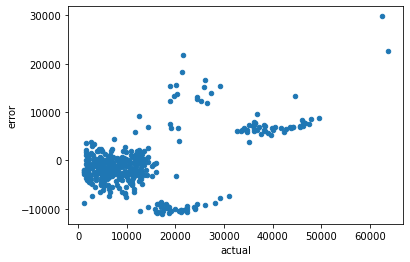

In [34]:
a.plot.scatter("actual", "error")

In [35]:
mse_test = (a.error ** 2).mean()
mse_test

33892347.11869648

In [36]:
from sklearn import metrics

In [37]:
metrics.mean_squared_error(y_test, y_test_pred)

33892347.118696496

In [38]:
import math

In [39]:
rmse_test = math.sqrt(mse_test)
rmse_test

5821.713417774571

In [40]:
y_test_pred.std()

10359.661593231554

In [41]:
metrics.mean_squared_error(y_test, y_test_pred)/metrics.mean_squared_error(y_train, y_train_pred)

0.899375308848974

In [42]:
baseline_prediction = y_train.mean()

In [43]:
sse = ((y_train - y_train_pred)**2).sum()
sst = ((y_train.mean() - y_train) ** 2).sum()
sse/sst

0.2544213545346281

In [44]:
1-sse/sst

0.7455786454653719

In [45]:
metrics.r2_score(y_train, y_train_pred)

0.7455786454653719

In [46]:
metrics.r2_score(y_test, y_test_pred)

0.7627582187528817

In [47]:
sse = ((y_test - y_test_pred)**2).sum()
sst = ((y_train.mean() - y_test) ** 2).sum()
1 - sse/sst

0.7627954448002803

In [48]:
sse = ((y_test - y_test_pred)**2).sum()
sst = ((y_test.mean() - y_test) ** 2).sum()
1 - sse/sst

0.7627582187528817

In [49]:
from sklearn import model_selection


target = "charges"

y = df[target] # label

X = df.drop(columns=target) # features


# Derives feature
X["high_bmi"] = X.bmi>33
X = pd.get_dummies(X, drop_first=True)
X["age_band"] = np.where(X.age<40, "b1", np.where(X.age > 70 , "b3", "b2"))

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 123)


poly = preprocessing.PolynomialFeatures(degree=2, include_bias=False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

scaler = preprocessing.StandardScaler() # For every feature mean = 0, std = 1 (approax)


scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

est = linear_model.LinearRegression()

est.fit(X_train, y_train) # train the model

y_train_pred = est.predict(X_train)

y_test_pred = est.predict(X_test)


print("rmse train", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("rmse test", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("r2 train", metrics.r2_score(y_train, y_train_pred))
print("r2 test", metrics.r2_score(y_test, y_test_pred))

rmse train 4771.387319619104
rmse test 4539.216698593353
r2 train 0.8462970442199366
r2 test 0.8557714083990222


In [50]:
a = np.random.randint(0, 10, (5, 3))
a

array([[6, 4, 5],
       [0, 5, 1],
       [8, 6, 3],
       [2, 4, 6],
       [5, 5, 0]])

In [51]:
poly = preprocessing.PolynomialFeatures(degree=2, include_bias=False)
pd.DataFrame(poly.fit_transform(a))

,0,1,2,3,4,5,6,7,8
0,6.0,4.0,5.0,36.0,24.0,30.0,16.0,20.0,25.0
1,0.0,5.0,1.0,0.0,0.0,0.0,25.0,5.0,1.0
2,8.0,6.0,3.0,64.0,48.0,24.0,36.0,18.0,9.0
3,2.0,4.0,6.0,4.0,8.0,12.0,16.0,24.0,36.0
4,5.0,5.0,0.0,25.0,25.0,0.0,25.0,0.0,0.0


rmse train 3429.8749620044023
rmse test 13052.998962326696
r2 train 0.920576421455237
r2 test -0.19264210440078955


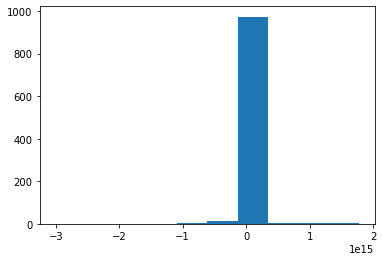

In [52]:
from sklearn import model_selection
from sklearn import pipeline


target = "charges"

y = df[target] # label

X = df.drop(columns=target) # features


# Derives feature
X["high_bmi"] = X.bmi>33
X = pd.get_dummies(X, drop_first=True)
X["age_band"] = np.where(X.age<40, "b1", np.where(X.age > 70 , "b3", "b2"))

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 123)


pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.LinearRegression())
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)

print("rmse train", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("rmse test", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("r2 train", metrics.r2_score(y_train, y_train_pred))
print("r2 test", metrics.r2_score(y_test, y_test_pred))

est = pipe.steps[-1][-1]
est.intercept_, est.coef_
plt.hist(est.coef_);

In [53]:
a = np.random.randint(0, 10, (5, 1000))
poly = preprocessing.PolynomialFeatures(degree=2, include_bias=False)
pd.DataFrame(poly.fit_transform(a)).shape

(5, 501500)

rmse train 0.2914967963849288
rmse test 0.9119067431118383
r2 train 0.9021044101163123
r2 test -0.052983592613630615


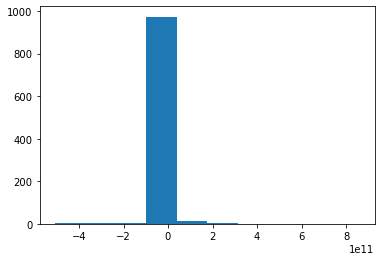

In [56]:
from sklearn import model_selection
from sklearn import pipeline


target = "charges"

y = np.log(df[target]) # label

X = df.drop(columns=target) # features


# Derives feature
X["high_bmi"] = X.bmi>33
X = pd.get_dummies(X, drop_first=True)
X["age_band"] = np.where(X.age<40, "b1", np.where(X.age > 70 , "b3", "b2"))

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 123)


pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.LinearRegression())
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)

print("rmse train", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("rmse test", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("r2 train", metrics.r2_score(y_train, y_train_pred))
print("r2 test", metrics.r2_score(y_test, y_test_pred))

est = pipe.steps[-1][-1]
est.intercept_, est.coef_
plt.hist(est.coef_);

In [57]:
est.coef_

array([ 2.32718268e+01,  1.58088451e+01, -1.36262688e+01,  2.29050537e+11,
        8.59133270e+11,  2.75052187e+11, -1.99496937e+11,  3.28440867e+11,
       -1.59815607e+11, -4.68050082e+11, -1.62686837e+02,  4.80277667e+01,
        4.37861633e+00, -9.70780948e+09, -5.08262810e+11, -4.11491266e+10,
        4.53971115e+10, -4.00657287e+08,  1.05037375e+10, -3.03404270e+09,
       -8.86652241e+01,  6.78981552e+01, -6.96032105e+09, -4.70122403e+09,
        1.20105438e+10,  5.67202464e+10,  9.10312260e+09,  6.21193934e+09,
        4.01879155e+09, -3.30200195e+00,  2.66602540e+09, -2.79575135e+09,
       -5.41058876e+09,  6.68465925e+09, -4.46845276e+09, -1.41691770e+09,
       -8.24361262e+09, -8.16172196e+10,  5.46948205e+09, -1.02880835e+10,
       -6.54802935e+09, -8.53836409e+09, -3.28013113e+09,  7.55078837e+09,
       -2.99983498e+11, -4.54692670e+09,  1.35437550e+10, -7.22212931e+09,
       -7.60799229e+09,  5.31246654e+09, -8.80179277e+10, -4.54398468e+09,
        1.34303143e+10, -

rmse train 0.3988349914407739
rmse test 0.3433666135864429
r2 train 0.8167339316644002
r2 test 0.8507078816077442


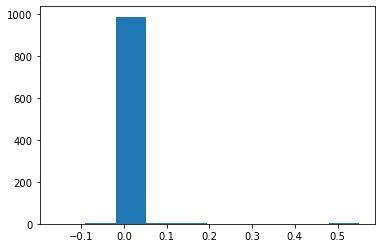

In [64]:
from sklearn import model_selection
from sklearn import pipeline


target = "charges"

y = np.log(df[target]) # label

X = df.drop(columns=target) # features


# Derives feature
X["high_bmi"] = X.bmi>33
X = pd.get_dummies(X, drop_first=True)
X["age_band"] = np.where(X.age<40, "b1", np.where(X.age > 70 , "b3", "b2"))

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 123)


pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.Lasso(alpha=0.01))
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)

print("rmse train", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("rmse test", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("r2 train", metrics.r2_score(y_train, y_train_pred))
print("r2 test", metrics.r2_score(y_test, y_test_pred))

est = pipe.steps[-1][-1]
est.intercept_, est.coef_
plt.hist(est.coef_);

In [62]:
est.coef_

array([ 0.,  0.,  0.,  0., -0.,  0., -0.,  0., -0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,
        0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0., -0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,
        0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0

rmse train 0.3744578722982732
rmse test 0.3595378889613308
r2 train 0.8384520371241194
r2 test 0.8363145494506682


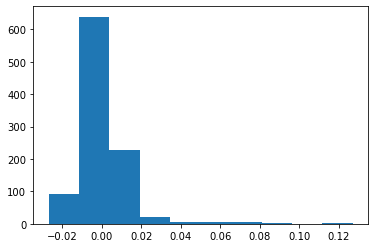

In [70]:
from sklearn import model_selection
from sklearn import pipeline


target = "charges"

y = np.log(df[target]) # label

X = df.drop(columns=target) # features


# Derives feature
X["high_bmi"] = X.bmi>33
X = pd.get_dummies(X, drop_first=True)
X["age_band"] = np.where(X.age<40, "b1", np.where(X.age > 70 , "b3", "b2"))

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 123)


pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.Ridge(alpha=100.0))
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)

print("rmse train", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("rmse test", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("r2 train", metrics.r2_score(y_train, y_train_pred))
print("r2 test", metrics.r2_score(y_test, y_test_pred))

est = pipe.steps[-1][-1]
est.intercept_, est.coef_
plt.hist(est.coef_);